# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isnull().sum() / len(users))  # Proporción de valores nulos



user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isnull().sum())
print(usage.isnull().sum() / len(usage))

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **igno
 - ra o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Diagnostico**

 **Dateset users** 
 
   - Para los datos de city en el dataset de users, hay un 11,725% de valores nulos, en el cual presenta un porcentaje moderado de valores faltantes, investigar si se puede imputar (ej. usando información externa o patrones) o mantener como “Unknown” si no afecta el análisis principal.
     
   - Para churn_date alto porcentaje de nulos. Sin embargo, en este caso es coherente los valores nulos representan usuarios que no han cancelado.
Por lo tanto, no eliminar la columna. Convertirla en una variable binaria (churned / not churned) para análisis de retención.

**Dataset usage**

   - date muy bajo porcentaje de nulos. Eliminar esas filas o imputar si el impacto es mínimo.

   - duration alto porcentaje de nulos. Puede deberse a que no todos los tipos de uso requieren duración (ej. mensajes). Analizar por tipo de registro antes de eliminar. Probablemente los nulos sean estructurales y no errores.

   - length porcentaje alto de nulos, posiblemente porque solo aplica a cierto tipo de evento (ej. SMS). Evaluar relación con la columna type. Si es dependiente del tipo, mantenerla y tratar nulos como no aplicables.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
print(users.dtypes)

user_id        int64
first_name    object
last_name     object
age            int64
city          object
reg_date      object
plan          object
churn_date    object
dtype: object


- La columna `user_id` tiene su tipo correcto
- La columna `age` tiene su tipo de acuerdo a los numeros enteros 

In [13]:
# explorar columnas numéricas de usage
print(usage.dtypes)

id            int64
user_id       int64
type         object
date         object
duration    float64
length      float64
dtype: object


- Las columnas `id` y `user_id` tienen su tipo de columna adecuada para los numeros enteros.
- Las columnas `duration` y `lenght` tambien estan correctos ya que son numeros con decimales

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe())

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` tiene 7 ciudades únicas, siendo Bogotá la más frecuente
- La columna `plan` existen 2 planes, siendo Básico el más común (2595 usuarios)

In [15]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` tiene 2 categorías, siendo “text” la más frecuente


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

**Diagnóstico**

- churn_date (object) los valores nulos funcionan como sentinel, indicando usuarios que no han cancelado. No eliminar. Convertir en variable binaria (churned = 1 / active = 0) para análisis.

- duration (float64) más del 50% son nulos. Es probable que los nulos actúen como sentinel cuando el tipo de uso no requiere duración (ej. mensajes). Validar relación con type. Mantener como NA si es estructural.

- length (float64) casi 45% nulos. Puede ser sentinel para registros donde no aplica (ej. llamadas). Analizar por type y conservar como NA si es coherente con la lógica del negocio.

- age (int64) no presenta nulos, pero podrían existir valores inválidos (ej. edades negativas o extremadamente altas). Validar rango lógico (ej. 18–100).

- reg_date y date (object) aunque no tienen muchos nulos, están como texto. Convertir a formato datetime para evitar errores en análisis temporal.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [17]:
print("Tipo antes:", users['reg_date'].dtype)
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
print("Tipo después:", users['reg_date'].dtype)


Tipo antes: datetime64[ns]
Tipo después: datetime64[ns]


In [18]:
print(users['reg_date'].head())
print(users['reg_date'].dtypes)

0   2022-01-01 00:00:00.000000000
1   2022-01-01 06:34:17.914478619
2   2022-01-01 13:08:35.828957239
3   2022-01-01 19:42:53.743435858
4   2022-01-02 02:17:11.657914478
Name: reg_date, dtype: datetime64[ns]
datetime64[ns]


In [19]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [20]:
# Revisar los años presentes en `reg_date` de users
users['año'] = users['reg_date'].dt.year

# Ve todos los años únicos presentes
print("Años presentes en los datos:")
print(sorted(users['año'].unique()))

# Cuenta registros por año
conteo_años = users['año'].value_counts().sort_index()
print("Registros por año:")
print(conteo_años)

Años presentes en los datos:
[2022, 2023, 2024, 2026]
Registros por año:
2022    1314
2023    1316
2024    1330
2026      40
Name: año, dtype: int64


En `reg_date`se encontro el 2026 como año futuro en el cual se encuentra 40 registros

In [21]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

# Ver solo los años únicos ordenados
print("Años únicos:", sorted(usage['date'].dt.year.unique()))

# Ver el rango completo
print("Año mínimo:", usage['date'].dt.year.min())
print("Año máximo:", usage['date'].dt.year.max())

Años únicos: [2024.0, nan]
Año mínimo: 2024.0
Año máximo: 2024.0


En `date`, solo estan los datos del año 2024, pero hay fechas faltantes
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

**Diagnóstico**

- reg_date (users):
Se encontraron 40 registros con el año 2026, que es un año futuro respecto al periodo de análisis (hasta 2024). Revisar esos registros para verificar si es un error. Si no pueden validarse, excluirlos del análisis y documentar la decisión.

- date (usage):
Solo hay datos del año 2024, lo cual es consistente con el análisis. Sin embargo, existen valores NaN. Revisar los registros con fechas faltantes y, si son pocos, eliminarlos o corregirlos si es posible.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [22]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
print(f"Mediana real (sin -999): {age_mediana}")

users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

Mediana real (sin -999): 48.0


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
print("Valores nulos en city ahora:", users['city'].isna().sum())

Valores nulos en city ahora: 565


In [24]:
# Contar registros con año 2026 antes del cambio
registros_2026_antes = (users['reg_date'].dt.year == 2026).sum()
print(f"Registros con año 2026 ANTES: {registros_2026_antes}")

Registros con año 2026 ANTES: 40


In [25]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verificar cambios
registros_2026_despues = (users['reg_date'].dt.year == 2026).sum()
print(f"Registros con año 2026 DESPUÉS: {registros_2026_despues}")

Registros con año 2026 DESPUÉS: 0


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [26]:
# Verificación MAR en usage (Missing At Random) para duration


In [27]:
# Verificación MAR en usage (Missing At Random) para length


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

**Diagnóstico** 
- Los valores nulos en `duration` aparecen principalmente en ciertos tipos de registro (por ejemplo, cuando el tipo no requiere duración, como mensajes).

- Los valores nulos en `length` también dependen del tipo de actividad (por ejemplo, llamadas no tienen longitud de mensaje).

Se dejarán los valores nulos como están, ya que:

- Son estructurales y coherentes con el tipo de registro.
- Representan ausencia lógica de información (no todos los tipos necesitan duration o length).
- Imputarlos podría distorsionar el análisis.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [28]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',      # Total de mensajes por usuario
    'is_call': 'sum',      # Total de llamadas por usuario
    'duration': 'sum'   # Duración total de llamadas
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas', 
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [30]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,año,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [31]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,año,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,2023.034000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,0.866044,2.358416,2.144238,18.168095
min,10000.000000,18.000000,2022.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,2022.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,2023.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,2024.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,2026.000000,17.000000,15.000000,155.690000


In [32]:
# Distribución porcentual del tipo de plan
plan_distribution = user_profile['plan'].value_counts(normalize=True) * 100
print("Distribución de planes (%):")
print(plan_distribution.round(2))

Distribución de planes (%):
Basico     64.88
Premium    35.12
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

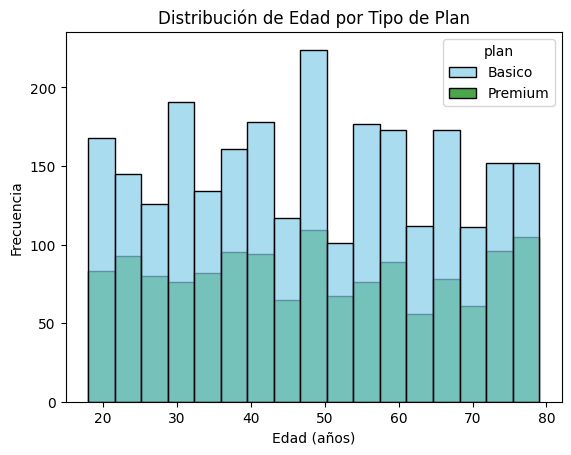

In [33]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', 
             palette=['skyblue','green'], alpha=0.7)
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución es uniforme en el plan premium ya que algunos datos estan bastante parejo, en cambio el plan básico tiene una distribución campana.

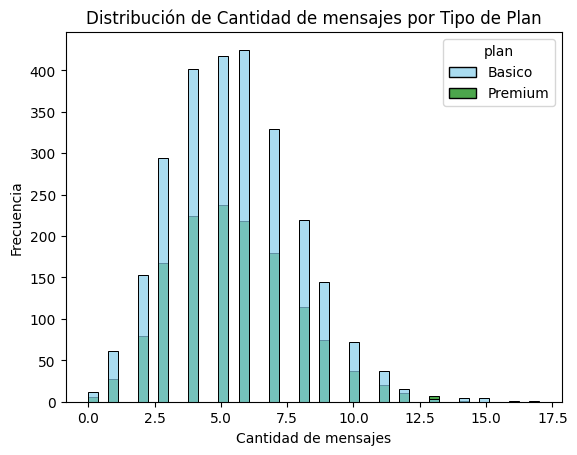

In [34]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', 
             palette=['skyblue','green'], alpha=0.7)
plt.title('Distribución de Cantidad de mensajes por Tipo de Plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Tiene una distribución sesgo a la derecha, ya que la mayoría de usuarios envian pocos mensajes

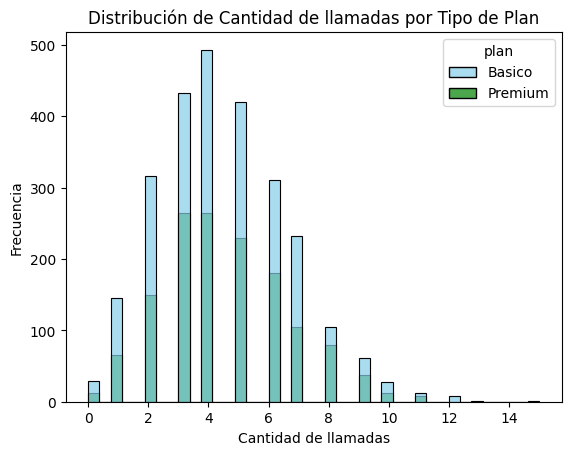

In [35]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', 
             palette=['skyblue','green'], alpha=0.7)
plt.title('Distribución de Cantidad de llamadas por Tipo de Plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución con sesgo a la derecha, igual que la anterior que los usuarios no realizan tantas llamadas en ambos planes.

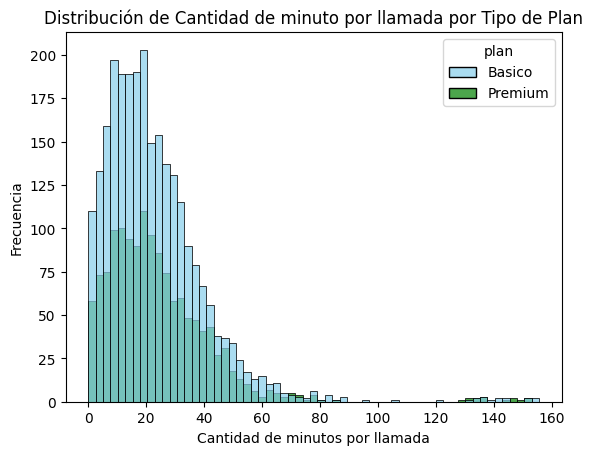

In [36]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', 
             palette=['skyblue','green'], alpha=0.7)
plt.title('Distribución de Cantidad de minuto por llamada por Tipo de Plan')
plt.xlabel('Cantidad de minutos por llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Totalmente tiene una distribución sesgo a la derecha, los usuarios prefieren llamadas cortas en ambos planes.


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

Procesando columna: age
Datos disponibles: 4000 valores
------------------------------
Procesando columna: cant_mensajes
Datos disponibles: 3999 valores
------------------------------
Procesando columna: cant_llamadas
Datos disponibles: 3999 valores
------------------------------
Procesando columna: cant_minutos_llamada
Datos disponibles: 3999 valores
------------------------------
Creando boxplot para: age


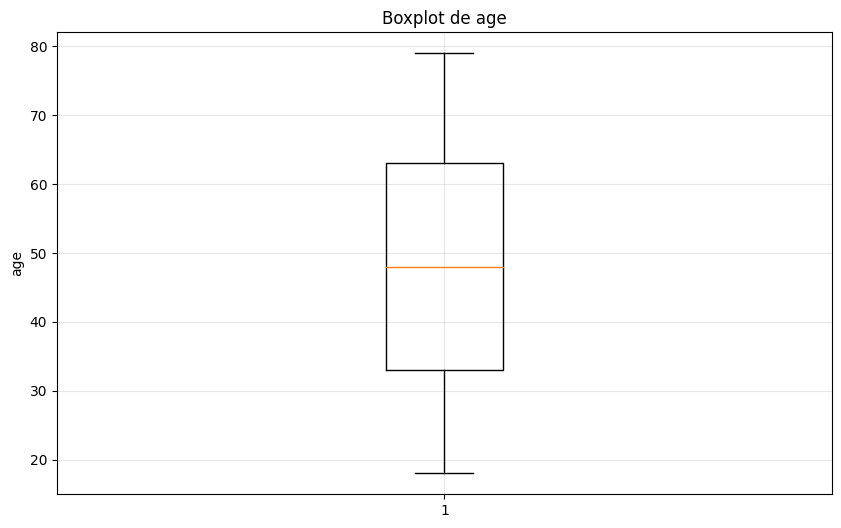

Boxplot de age completado
Creando boxplot para: cant_mensajes


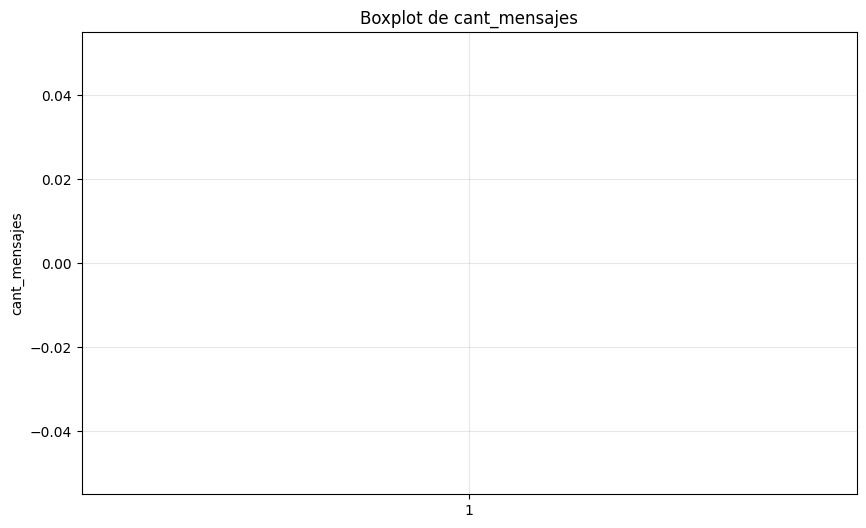

Boxplot de cant_mensajes completado
Creando boxplot para: cant_llamadas


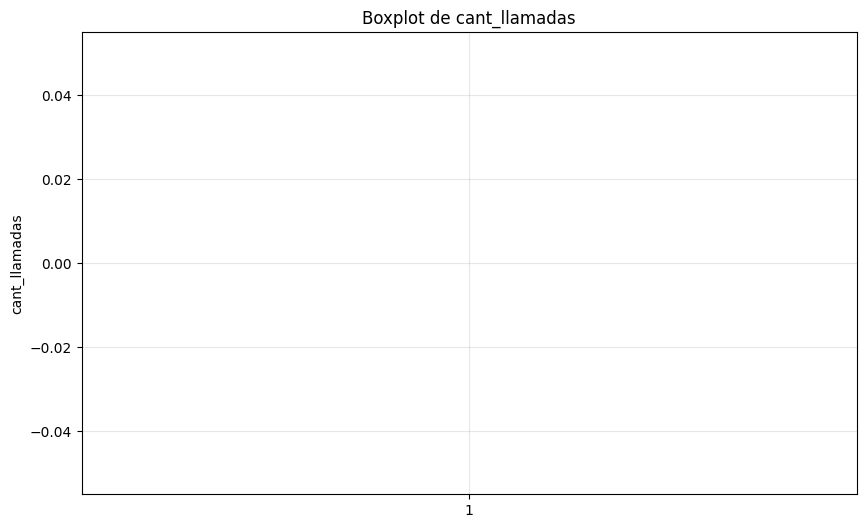

Boxplot de cant_llamadas completado
Creando boxplot para: cant_minutos_llamada


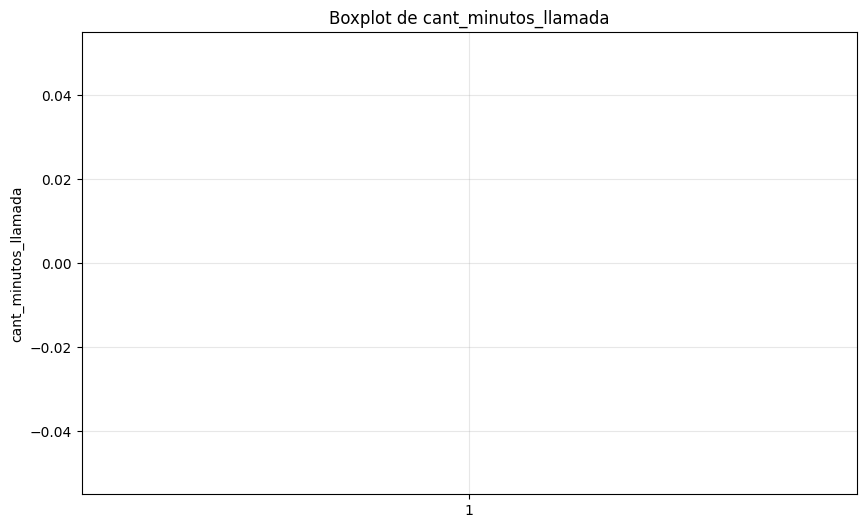

Boxplot de cant_minutos_llamada completado


In [37]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for columna in columnas_numericas: 
    print(f"Procesando columna: {columna}")
    print(f"Datos disponibles: {user_profile[columna].count()} valores")
    print("-" * 30)

for columna in columnas_numericas: 
    print(f"Creando boxplot para: {columna}")
    
    plt.figure(figsize=(10, 6))  # Tamaño más grande
    plt.boxplot(user_profile[columna])     # UNA columna por vez
    plt.title(f'Boxplot de {columna}')
    plt.ylabel(columna)
    plt.grid(True, alpha=0.3)    # Rejilla para mejor visualización
    plt.show()
    
    print(f"Boxplot de {columna} completado")
    print("=" * 40)

💡Insights: 
- Age: no presenta outliers, tienen un rango normal de edades
- cant_mensajes: no se puede observar si tiene o no outliers ya que posiblemente la mayoría de valores son similiares
- cant_llamadas: no exitesn outliers, algunos usuarios llaman muchos, otro muy poco
- cant_minutos_llamada: Hay usuarios que hablan horas vs usuarios que hacen llamadas cortas.

In [38]:
for columna in columnas_numericas:
    print(f"\n=== {columna} ===")
    print(f"Min: {user_profile[columna].min()}")
    print(f"Max: {user_profile[columna].max()}")
    print(f"Promedio: {user_profile[columna].mean():.2f}")
    print(f"Rango: {user_profile[columna].max() - user_profile[columna].min()}")


=== age ===
Min: 18.0
Max: 79.0
Promedio: 48.14
Rango: 61.0

=== cant_mensajes ===
Min: 0.0
Max: 17.0
Promedio: 5.52
Rango: 17.0

=== cant_llamadas ===
Min: 0.0
Max: 15.0
Promedio: 4.48
Rango: 15.0

=== cant_minutos_llamada ===
Min: 0.0
Max: 155.69
Promedio: 23.32
Rango: 155.69


In [39]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Paso 1: Calcular cuartiles
Q1 = user_profile[columnas_limites].quantile(0.25)  # 25% de los datos
Q3 = user_profile[columnas_limites].quantile(0.75)  # 75% de los datos
IQR = Q3 - Q1                    # Rango intercuartílico

# Paso 2: Calcular límites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR


In [40]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Mantener los outliers, ya que es normal que algunos usuarios envíen muchos más mensajes que otros. Estos valores pueden representar usuarios con mayor actividad y son relevantes para el análisis de comportamiento.
- cant_llamadas: Mantener los outliers porque reflejan variaciones reales en el uso del servicio. Algunos usuarios pueden realizar muchas más llamadas, lo cual es información valiosa para entender patrones de consumo.
- cant_minutos_llamada: Mantener los outliers, ya que pueden representar usuarios que realizan llamadas largas o frecuentes. Eliminarlos podría perder información importante sobre usuarios con alto uso del servicio.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [41]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

# Aplicar la función
user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [42]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,año,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [43]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30, 'Joven',
    np.where(
        user_profile['age'] <60, 
        'Adulto',
        'Adulto Mayor'
    )
)

In [44]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,año,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

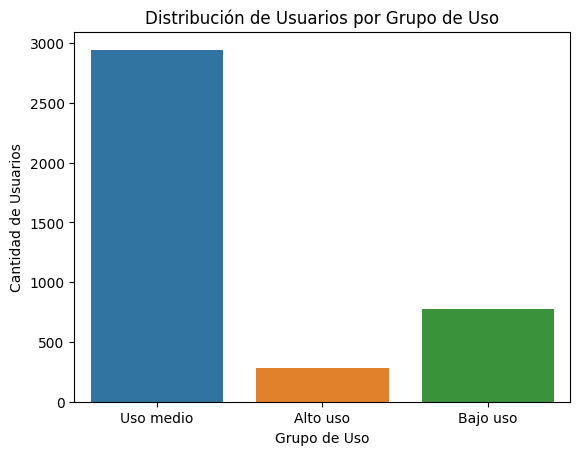

In [45]:
# Visualización de los segmentos por uso
sns.countplot(data= user_profile, x='grupo_uso')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

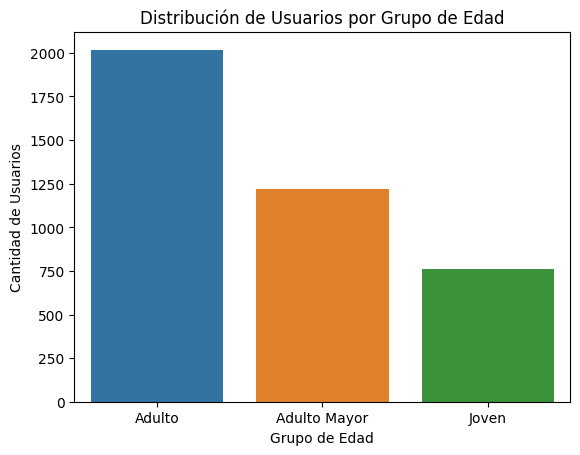

In [46]:
# Visualización de los segmentos por edad
sns.countplot(data= user_profile, x='grupo_edad')
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Primero que hay una columna en el cual se encuentra en el formato erroneo (churn_date), ya que deberia ser formato boolean
- Para mi la columna cantidad de llamadas, se puede eliminar y solo manejar la columna de cantidad de minutos por llamada, ya que se manejaría es por los minutos que el usuario usa en sus planes más no la cantidad de veces que realiza una llamada


🔍 **Segmentos por Edad**
- Se identificó que el grupo de edad Adulto (Entre 30 y 60 años) es el 50% de los usuarios que tienen plan con ConnectaTel
- Baja participación de usuarios jovenes, en el cual puede ser por posibles uso de planes prepago, o uso de servicios OTT(Whatsapp, streaming, etc.)

📊 **Segmentos por Nivel de Uso**
- La mayoria de los clientes tienen uso medio, quiere decir que la mayoria utiliza el servicio de manera regular pero no intensiva
- Muy pocos usuarios de alto consumo, pero estos usuarios suelen ser los mas valiosos economicamente


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- Las campañas comerciales deberian enfocarse principalmente en adultos, ya que representan el segmento principal de los ingresos
- Crear planes económicos o planes estudiantiles, o promociones de datos móviles o redes sociales
- Como hay un uso regular de los planes, se puede ofrecer upgrades de plan, incentivar mayor consumo con paquetes de datos, servicios de streaming o bundles
- Hacer seguimiento a los usuarios de bajo consumo ya que pueden representar clientes pocos comprometidos o clientes que pueden cambiar de operador, y para reternelos se puede ofrecer promociones, bonos de datos o lo que muchas empresas estan haciendo ahora es dar descuentos en upgrades


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`